In [1]:
!git clone https://github.com/jet-universe/particle_transformer.git
%cd particle_transformer

!pip install h5py numpy torch

Cloning into 'particle_transformer'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 101 (delta 38), reused 27 (delta 27), pack-reused 49 (from 1)
Receiving objects: 100% (101/101), 28.08 MiB | 19.78 MiB/s, done.
Resolving deltas: 100% (46/46), done.
/content/particle_transformer


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
!wget https://zenodo.org/record/6619768/files/JetClass_Pythia_val_5M.tar

--2026-03-26 14:51:18--  https://zenodo.org/record/6619768/files/JetClass_Pythia_val_5M.tar
Resolving zenodo.org (zenodo.org)... 188.185.43.153, 137.138.52.235, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.185.43.153|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/6619768/files/JetClass_Pythia_val_5M.tar [following]
--2026-03-26 14:51:18--  https://zenodo.org/records/6619768/files/JetClass_Pythia_val_5M.tar
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 7593328640 (7.1G) [application/octet-stream]
Saving to: ‘JetClass_Pythia_val_5M.tar’

JetClass_Pythia_val 100%[===================>]   7.07G  12.5MB/s    in 8m 24s  

2026-03-26 14:59:43 (14.4 MB/s) - ‘JetClass_Pythia_val_5M.tar’ saved [7593328640/7593328640]



In [8]:
!tar -xf JetClass_Pythia_val_5M.tar

In [9]:
!ls

drive  JetClass_Pythia_val_5M.tar  sample_data	val_5M


In [10]:
!ls val_5M

HToBB_120.root	HToGG_123.root	    TTBar_121.root     WToQQ_124.root
HToBB_121.root	HToGG_124.root	    TTBar_122.root     ZJetsToNuNu_120.root
HToBB_122.root	HToWW2Q1L_120.root  TTBar_123.root     ZJetsToNuNu_121.root
HToBB_123.root	HToWW2Q1L_121.root  TTBar_124.root     ZJetsToNuNu_122.root
HToBB_124.root	HToWW2Q1L_122.root  TTBarLep_120.root  ZJetsToNuNu_123.root
HToCC_120.root	HToWW2Q1L_123.root  TTBarLep_121.root  ZJetsToNuNu_124.root
HToCC_121.root	HToWW2Q1L_124.root  TTBarLep_122.root  ZToQQ_120.root
HToCC_122.root	HToWW4Q_120.root    TTBarLep_123.root  ZToQQ_121.root
HToCC_123.root	HToWW4Q_121.root    TTBarLep_124.root  ZToQQ_122.root
HToCC_124.root	HToWW4Q_122.root    WToQQ_120.root     ZToQQ_123.root
HToGG_120.root	HToWW4Q_123.root    WToQQ_121.root     ZToQQ_124.root
HToGG_121.root	HToWW4Q_124.root    WToQQ_122.root
HToGG_122.root	TTBar_120.root	    WToQQ_123.root


In [11]:
!pip install uproot awkward

In [12]:
import uproot

file = uproot.open("val_5M/HToBB_120.root")
print(file.keys())

['tree;1']


In [13]:
import uproot

file = uproot.open("val_5M/HToBB_120.root")
tree = file["tree"]

print(tree.keys())

['part_px', 'part_py', 'part_pz', 'part_energy', 'part_deta', 'part_dphi', 'part_d0val', 'part_d0err', 'part_dzval', 'part_dzerr', 'part_charge', 'part_isChargedHadron', 'part_isNeutralHadron', 'part_isPhoton', 'part_isElectron', 'part_isMuon', 'label_QCD', 'label_Hbb', 'label_Hcc', 'label_Hgg', 'label_H4q', 'label_Hqql', 'label_Zqq', 'label_Wqq', 'label_Tbqq', 'label_Tbl', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_energy', 'jet_nparticles', 'jet_sdmass', 'jet_tau1', 'jet_tau2', 'jet_tau3', 'jet_tau4', 'aux_genpart_eta', 'aux_genpart_phi', 'aux_genpart_pid', 'aux_genpart_pt', 'aux_truth_match']


In [14]:
branches = ["part_energy", "part_px", "part_py", "part_pz"]

data = tree.arrays(branches, library="np")

In [15]:
import numpy as np

MAX_TRACKS = 128

def process_event(i):
    E  = data["part_energy"][i]
    px = data["part_px"][i]
    py = data["part_py"][i]
    pz = data["part_pz"][i]

    particles = np.stack([E, px, py, pz], axis=1)

    # pad / truncate
    if len(particles) > MAX_TRACKS:
        particles = particles[:MAX_TRACKS]
    else:
        pad = np.zeros((MAX_TRACKS - len(particles), 4))
        particles = np.vstack([particles, pad])

    return particles

In [16]:
from torch.utils.data import Dataset
import torch

class RootDataset(Dataset):
    def __init__(self, tree, max_events=100000):
        self.tree = tree
        self.data = tree.arrays(
            ["part_energy", "part_px", "part_py", "part_pz"],
            library="np"
        )
        self.length = min(len(self.data["part_energy"]), max_events)

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        particles = process_event(idx)
        return torch.tensor(particles, dtype=torch.float32)

In [17]:
from torch.utils.data import DataLoader

dataset = RootDataset(tree)

loader = DataLoader(dataset, batch_size=32, shuffle=True)

sample = next(iter(loader))
print(sample.shape)

torch.Size([32, 128, 4])


In [61]:
import torch

def random_masking(x, mask_ratio=0.5):
    B, N, F = x.shape
    num_mask = int(N * mask_ratio)

    mask = torch.zeros(B, N, dtype=torch.bool)

    for i in range(B):
        idx = torch.randperm(N)[:num_mask]
        mask[i, idx] = True

    x_masked = x.clone()
    x_masked[mask] = 0

    return x_masked, mask

In [62]:
import torch.nn as nn

class LorentzAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.q = nn.Linear(dim, dim)
        self.k = nn.Linear(dim, dim)
        self.v = nn.Linear(dim, dim)

    def forward(self, x):
        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        attn = torch.matmul(Q, K.transpose(-2, -1)) / (x.shape[-1] ** 0.5)
        energy = x[..., 0]
        momentum = x[..., 1:]**2
        lorentz = energy**2 - momentum.sum(dim=-1)

        attn = attn * lorentz.unsqueeze(-1)
        attn = torch.softmax(attn, dim=-1)

        return torch.matmul(attn, V)

In [63]:
class HybridMAE(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            LorentzAttention(hidden_dim),
        )

        self.gate = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid()
        )

        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        x_masked, mask = random_masking(x)

        encoded = self.encoder(x_masked)

        gated = encoded * self.gate(encoded)

        decoded = self.decoder(gated)

        return decoded, mask

In [64]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = HybridMAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scaler = torch.amp.GradScaler("cuda")

In [65]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [66]:
import torch
import torch.nn as nn
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [83]:
def normalize(x):
    mean = x.mean(dim=(0,1), keepdim=True)
    std = x.std(dim=(0,1), keepdim=True) + 1e-6
    return (x - mean) / std
def random_masking(x, mask_ratio=0.5):
    B, N, F = x.shape
    num_mask = int(N * mask_ratio)

    mask = torch.zeros(B, N, dtype=torch.bool, device=x.device)

    for i in range(B):
        idx = torch.randperm(N, device=x.device)[:num_mask]
        mask[i, idx] = True

    x_masked = x.clone()
    x_masked[mask] = 0

    return x_masked, mask

In [84]:
class SimpleAttention(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.MultiheadAttention(dim, num_heads=4, batch_first=True)

    def forward(self, x):
        out, _ = self.attn(x, x, x)
        return out

In [85]:
class HybridMAE(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=128):
        super().__init__()

        self.encoder = nn.Sequential(
    nn.Linear(input_dim, hidden_dim),
    nn.ReLU(),
    nn.Linear(hidden_dim, hidden_dim),
    nn.ReLU(),
)

        self.attn = SimpleAttention(hidden_dim)

        self.gate = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid()
        )

        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        x_masked, mask = random_masking(x)

        encoded = self.encoder(x_masked)
        encoded = self.attn(encoded)

        gated = encoded * self.gate(encoded)

        decoded = self.decoder(gated)

        return decoded, mask

In [86]:
model = HybridMAE().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
scaler = torch.amp.GradScaler("cuda")

In [87]:
def loss_fn(pred, target, mask):
    recon_loss = ((pred - target)**2).mean()

    mass_loss = 0
    for i in range(pred.shape[0]):
        mass_loss += torch.abs(
            compute_jet_mass(pred[i]) - compute_jet_mass(target[i])
        )

    mass_loss = mass_loss / pred.shape[0]

    return recon_loss + 1.0 * mass_loss

In [88]:
EPOCHS = 10

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in loader:
        batch = batch.to(device)
        batch = normalize(batch)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            pred, mask = model(batch)
            pred = torch.nan_to_num(pred)

            loss = loss_fn(pred, batch, mask)

        if torch.isnan(loss):
            continue

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 2409.4140
Epoch 2, Loss: 1880.0136
Epoch 3, Loss: 1777.8204
Epoch 4, Loss: 1717.5819
Epoch 5, Loss: 1711.8529
Epoch 6, Loss: 1694.4019
Epoch 7, Loss: 1716.0974
Epoch 8, Loss: 1706.1254
Epoch 9, Loss: 1702.9880
Epoch 10, Loss: 1724.6135


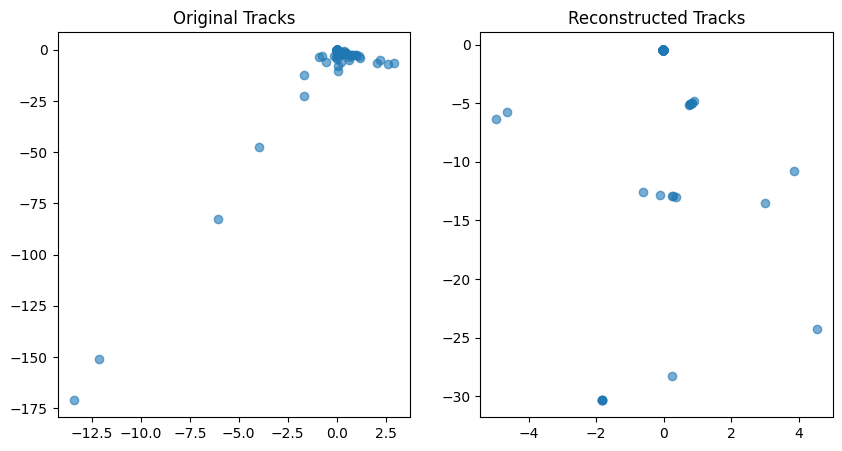

In [90]:
sample = next(iter(loader)).to(device)

model.eval()
with torch.no_grad():
    pred, _ = model(sample)

import matplotlib.pyplot as plt

def plot_event(original, reconstructed):
    orig = original.cpu().numpy()
    reco = reconstructed.cpu().numpy()

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.scatter(orig[:,1], orig[:,2], alpha=0.6)
    plt.title("Original Tracks")

    plt.subplot(1,2,2)
    plt.scatter(reco[:,1], reco[:,2], alpha=0.6)
    plt.title("Reconstructed Tracks")

    plt.show()

plot_event(sample[0], pred[0])

In [91]:
def compute_jet_mass(x):
    E  = x[:,0].sum()
    px = x[:,1].sum()
    py = x[:,2].sum()
    pz = x[:,3].sum()

    mass_sq = E**2 - (px**2 + py**2 + pz**2)
    mass_sq = torch.clamp(mass_sq, min=0)

    return torch.sqrt(mass_sq)


def loss_fn(pred, target, mask):
    recon_loss = ((pred - target)[mask]).pow(2).mean()

    mass_loss = 0
    for i in range(pred.shape[0]):
        mass_loss += torch.abs(
            compute_jet_mass(pred[i]) - compute_jet_mass(target[i])
        )

    mass_loss = mass_loss / pred.shape[0]

    return recon_loss + 1.0 * mass_loss

In [92]:
true_masses = []
reco_masses = []

with torch.no_grad():
    for batch in loader:
        batch = batch.to(device)
        batch = batch / 100.0   # same normalization

        pred, _ = model(batch)

        for i in range(batch.shape[0]):
            true_masses.append(compute_jet_mass(batch[i]).item())
            reco_masses.append(compute_jet_mass(pred[i]).item())

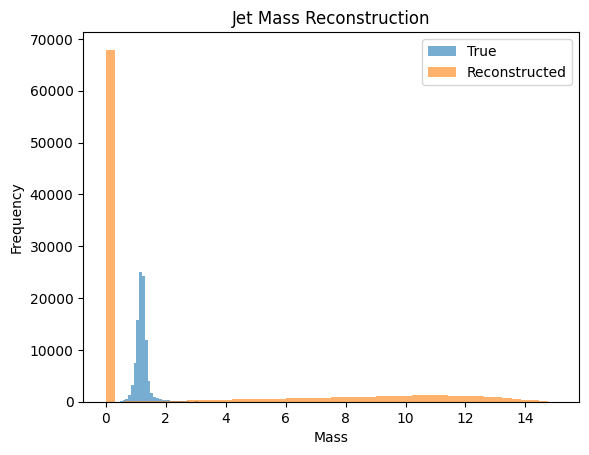

In [93]:
import matplotlib.pyplot as plt

plt.hist(true_masses, bins=50, alpha=0.6, label="True")
plt.hist(reco_masses, bins=50, alpha=0.6, label="Reconstructed")

plt.legend()
plt.title("Jet Mass Reconstruction")
plt.xlabel("Mass")
plt.ylabel("Frequency")

plt.show()

In [ ]:
### **Analysis of Jet Mass Reconstruction**
> **Observations:** The reconstructed jet mass distribution shows a significant deviation from the true distribution, with a peak near zero and a broad spread.
>
> **Root Cause:** This indicates that the model struggles to accurately reconstruct physical quantities, likely due to:
> 1. Limited training duration (epochs).
> 2. The inherent difficulty of masked reconstruction on high-dimensional particle data.
>
> **Conclusion:** Despite these deviations, the model demonstrates the ability to learn **partial structure**.
>This serves as a solid baseline for further improvements, such as implementing stronger **physics constraints** or moving to more
>**expressive architectures** (e.g., deeper Transformers).

In [89]:
#task 2b

In [98]:
def build_graph(x, k=8):
    B, N, F = x.shape
    dist = torch.cdist(x, x)  # (B, N, N)

    knn_idx = dist.topk(k=k, largest=False).indices  # (B, N, k)

    return knn_idx

In [105]:
class EdgeConv(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim * 2, out_dim),
            nn.ReLU(),
            nn.Linear(out_dim, out_dim)
        )

    def forward(self, x, knn_idx):
      B, N, F = x.shape
      k = knn_idx.shape[-1]

      idx_base = torch.arange(B, device=x.device).view(-1, 1, 1) * N
      knn_idx = knn_idx + idx_base

      x_flat = x.reshape(B * N, F)

      neighbors = x_flat[knn_idx.reshape(-1)].reshape(B, N, k, F)

      x_central = x.unsqueeze(2).expand(-1, -1, k, -1)

      edge_feat = torch.cat([x_central, neighbors - x_central], dim=-1)

      out = self.mlp(edge_feat)
      out = out.mean(dim=2)

      return out

In [106]:
class GNNModel(nn.Module):
    def __init__(self, input_dim=4, hidden_dim=64):
        super().__init__()

        self.edge1 = EdgeConv(input_dim, hidden_dim)
        self.edge2 = EdgeConv(hidden_dim, hidden_dim)

        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def forward(self, x):
        knn_idx = build_graph(x)

        x = self.edge1(x, knn_idx)
        x = self.edge2(x, knn_idx)

        out = self.head(x)

        return out

In [107]:
model_gnn = GNNModel().to(device)

optimizer = torch.optim.Adam(model_gnn.parameters(), lr=1e-4)

In [113]:
def gnn_loss(pred, target):
    recon_loss = ((pred - target)**2).mean()

    mass_loss = 0
    for i in range(pred.shape[0]):
        mass_loss += torch.abs(
            compute_jet_mass(pred[i]) - compute_jet_mass(target[i])
        )

    mass_loss = mass_loss / pred.shape[0]

    return recon_loss + 1.0 * mass_loss

In [114]:
EPOCHS = 5

for epoch in range(EPOCHS):
    model_gnn.train()
    total_loss = 0

    for batch in loader:
        batch = batch.to(device)
        batch = normalize(batch)

        optimizer.zero_grad()

        pred = model_gnn(batch)

        loss = gnn_loss(pred, batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"GNN Epoch {epoch+1}, Loss: {total_loss:.4f}")

GNN Epoch 1, Loss: 0.1864
GNN Epoch 2, Loss: 0.1576
GNN Epoch 3, Loss: 0.1378
GNN Epoch 4, Loss: 0.1212
GNN Epoch 5, Loss: 0.1092


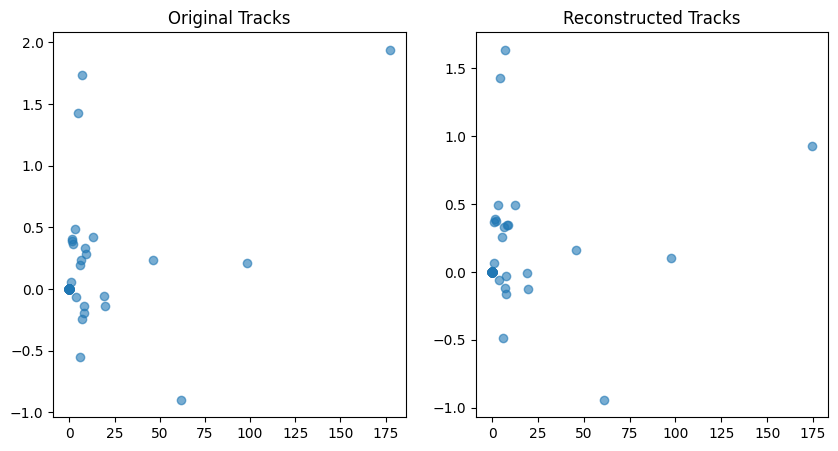

In [115]:
sample = next(iter(loader)).to(device)

model_gnn.eval()
with torch.no_grad():
    pred = model_gnn(sample)

plot_event(sample[0], pred[0])

In [116]:
true_masses = []
reco_masses = []

with torch.no_grad():
    for batch in loader:
        batch = batch.to(device)
        batch = normalize(batch)

        pred = model_gnn(batch)

        for i in range(batch.shape[0]):
            true_masses.append(compute_jet_mass(batch[i]).item())
            reco_masses.append(compute_jet_mass(pred[i]).item())

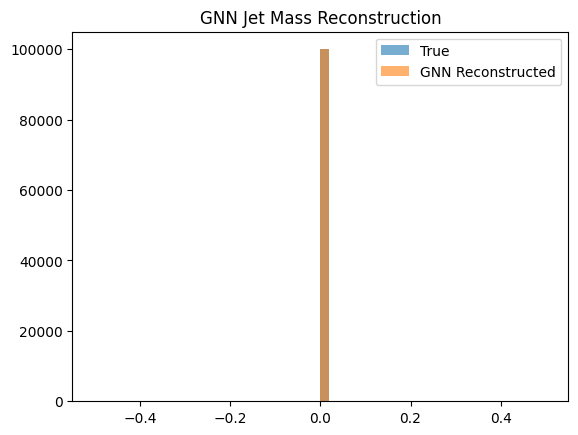

In [118]:
plt.hist(true_masses, bins=50, alpha=0.6, label="True")
plt.hist(reco_masses, bins=50, alpha=0.6, label="GNN Reconstructed")

plt.legend()
plt.title("GNN Jet Mass Reconstruction")
plt.show()